In [ ]:
Sys.time()

In [ ]:
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(repr))
suppressPackageStartupMessages(library(ggrastr))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(cowplot))
suppressPackageStartupMessages(library(ComplexHeatmap))
suppressPackageStartupMessages(library(circlize))
suppressPackageStartupMessages(library(RColorBrewer))
suppressPackageStartupMessages(library(ggplotify))

In [ ]:
projdir <- '/u/project/cluo/terencew/igvf/2023_YR2/final_figures'

donors <- c('C29', 'C37', 'C38', 'C39')
donor_order <- donors
donor_hexes <- c('#2851B0', '#C445B8', '#70373D', '#CFCF42')

tmp_order <- c('Start', 'Sendai', 'Delayed', 'Fail1', 'Inter1', 'Inter2', 'Fail2', 'IPS')
clust_hexes <- c('#C4B921', '#707332', '#9C4F43', '#4F7EB8', '#B07620', '#D698D0', '#0F2061', '#7F5194')
names(clust_hexes) <- tmp_order

base_theme <- theme(
    axis.line = element_blank(),
    panel.border = element_blank(),
    panel.grid = element_blank(),
    panel.background = element_blank(),
    plot.background = element_blank(),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    legend.position = 'none')

### B: fraction of Start cells among neighbors

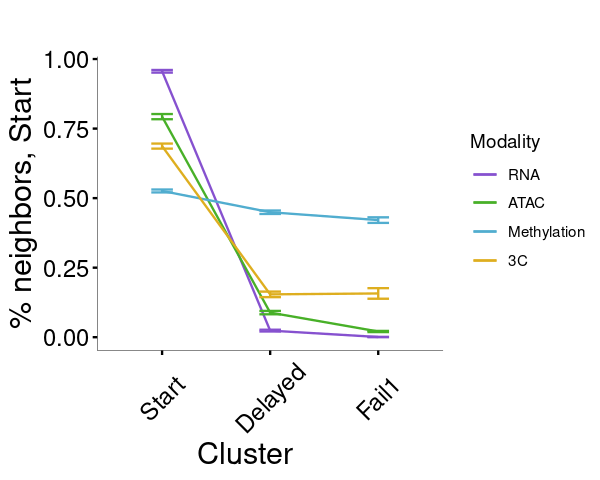

In [ ]:
select_cols <- c('cluster', 'start_prop')
mod_hexes <- c('#8651CF', '#48B028', '#51ADCF', '#DEAE1F')
mod_order <- c('RNA', 'ATAC', 'Methylation', '3C')
fail1_order <- c('Start', 'Delayed', 'Fail1')

rna_nn_path = paste0(projdir, '/csv/figure3/rna_nn_start_prop.csv')
rna_nn = as.data.frame(fread(rna_nn_path, sep='\t'))
rna_nn$cluster <- factor(rna_nn$cluster, levels=tmp_order)
rna_nn <- rna_nn %>% select(all_of(select_cols))
rna_nn$mod <- 'RNA'

atac_nn_path = paste0(projdir, '/csv/figure3/atac_nn_start_prop.csv')
atac_nn = as.data.frame(fread(atac_nn_path, sep='\t'))
atac_nn$cluster <- factor(atac_nn$cluster, levels=tmp_order)
atac_nn <- atac_nn %>% select(all_of(select_cols))
atac_nn$mod <- 'ATAC'

mcg_nn_path = paste0(projdir, '/csv/figure3/mcg_nn_start_prop.csv')
mcg_nn = as.data.frame(fread(mcg_nn_path, sep='\t'))
mcg_nn$cluster <- factor(mcg_nn$cluster, levels=tmp_order)
mcg_nn <- mcg_nn %>% select(all_of(select_cols))
mcg_nn$mod <- 'Methylation'

hic_nn_path = paste0(projdir, '/csv/figure3/hic_nn_start_prop.csv')
hic_nn = as.data.frame(fread(hic_nn_path, sep='\t'))
hic_nn$cluster <- factor(hic_nn$cluster, levels=tmp_order)
hic_nn <- hic_nn %>% select(all_of(select_cols))
hic_nn$mod <- '3C'

nn_list <- list(rna_nn, atac_nn, mcg_nn, hic_nn)
merged_nn <- do.call(rbind, nn_list)
merged_nn$mod <- factor(merged_nn$mod, levels=mod_order)
merged_nn$cluster <- factor(merged_nn$cluster, levels=fail1_order)

w = 5
h = 4
options(repr.plot.width=w, repr.plot.height=h)

ggplot(merged_nn, aes(x = cluster, y = start_prop, color = mod, group=mod)) +
  stat_summary(fun.data = mean_cl_normal, geom = "line") +
  stat_summary(fun.data = mean_cl_normal, geom = "errorbar", width = 0.2) +
    scale_color_manual(values=mod_hexes) +
  labs(x = "Cluster", y = "% neighbors, Start", title = '', color='Modality') +
  theme_minimal() +
  base_theme +
  theme(
      axis.title.x = element_text(size = 18, color='black', hjust=0.4),
      axis.title.y = element_text(size = 18, color='black', hjust=0.5),
      axis.text.x = element_text(size = 14, angle=45, color='black',hjust=0.5, vjust=0.5),
      axis.text.y = element_text(size = 14, color='black',hjust=0.5),
      plot.title = element_text(size = 24, hjust=0.4, face='plain'),
      axis.line = element_line(linewidth=0.1, color='black'),
        axis.ticks.x = element_line(),
        axis.ticks.y = element_line(),
        legend.position = 'right'
      )

### C: mCG UMAP of Start, Delayed, Fail1

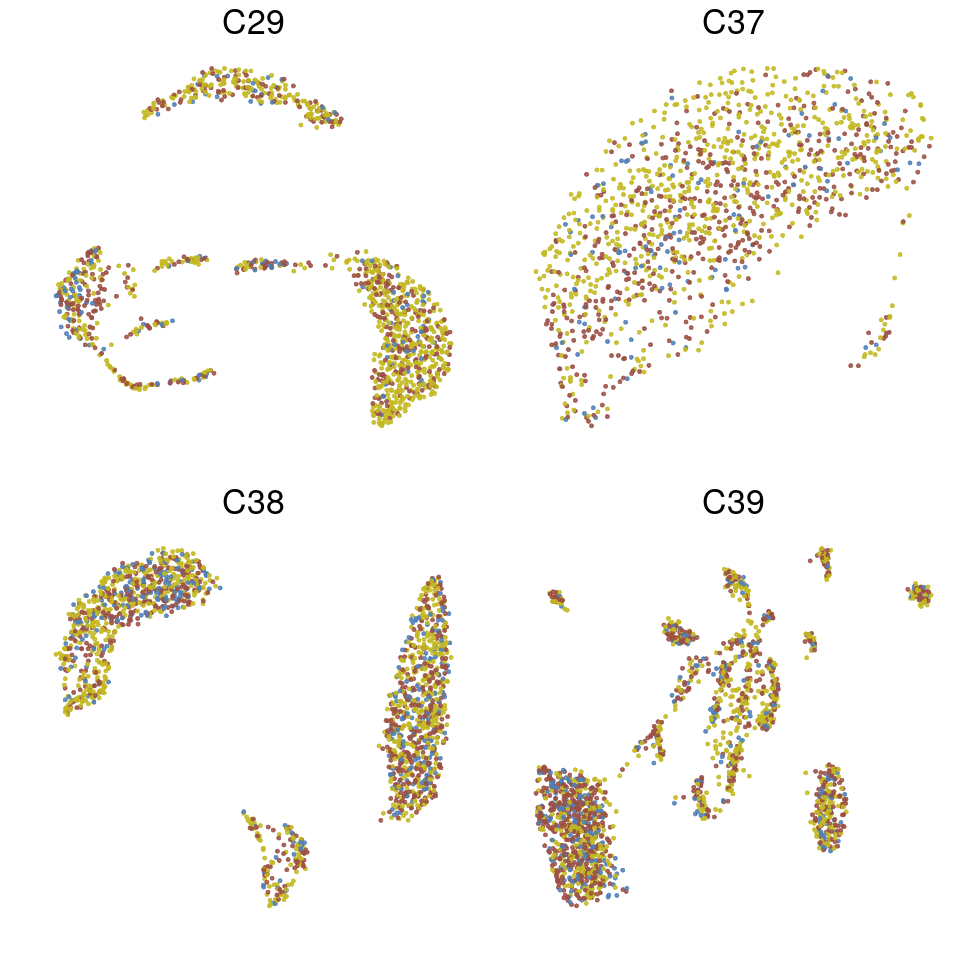

In [ ]:
fail1_order <- c('Start', 'Delayed', 'Fail1')

mcg_umap_path = paste0(projdir, '/csv/figure3/mcg_fail1_start_umap.csv')
mcg_umap = as.data.frame(fread(mcg_umap_path, sep='\t'))
mcg_umap$rna_cluster <- factor(mcg_umap$rna_cluster, levels=fail1_order)

set.seed(1)
shuffled_mcg_umap <- mcg_umap[sample(nrow(mcg_umap)), ]

plot_umap <- function(tmp_df, d) {
    donor_df <- tmp_df[tmp_df$line == d,]
    ggplot(donor_df, aes(x = umap0, y = umap1, color = rna_cluster)) +
    geom_point_rast(alpha=0.8, size=0.5) +
  labs(x = "", y = "", title=d, color='') +
  theme_bw() +
  base_theme +
    theme(
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
        plot.title = element_text(size=20, color='black', hjust=0.5),
    legend.position = 'none') +
    scale_color_manual(values=clust_hexes)
    }

plot_list <- list()

for (i in seq_along(donors)) {
    d <- donors[i]
    plot_list[[i]] <- plot_umap(shuffled_mcg_umap, d)
}
w = 8
h = 8
options(repr.plot.width=w, repr.plot.height=h)
combined_plot <- plot_grid(plotlist = plot_list, ncol=2, nrow=2)
combined_plot

### D: correlation of 100kb mCG between cell types

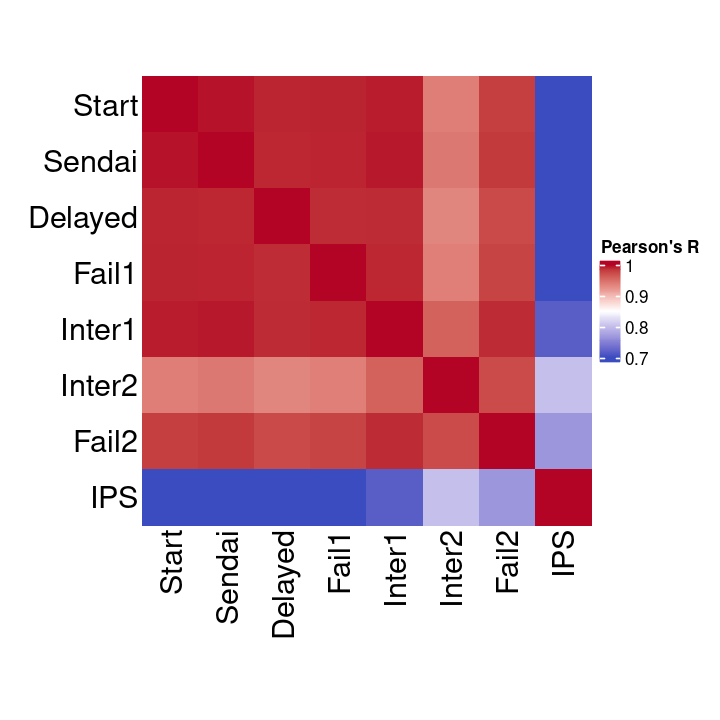

In [ ]:
mcg_corr_path = paste0(projdir, '/csv/figure3/mcg_celltype_5kb_bins_corr.csv')
mcg_corr = as.data.frame(fread(mcg_corr_path, sep='\t'))
rownames(mcg_corr) <- mcg_corr$V1
mcg_corr <- mcg_corr[,-1]

w = 6
h = 6
options(repr.plot.width=w, repr.plot.height=h)

ht <- Heatmap(mcg_corr,
        name = "Pearson's R",
        col = colorRamp2(c(0.7, 0.85, 1), c("#3B4CC0", "white", "#B40426")),
        cluster_rows = FALSE,
        cluster_columns = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 18),
        column_names_gp = gpar(fontsize = 18, rot = 90),
        heatmap_width = unit(12, "cm"),
        heatmap_height = unit(12, "cm"))

ht

### E: enhancer mCG across the Fail1/productive branches

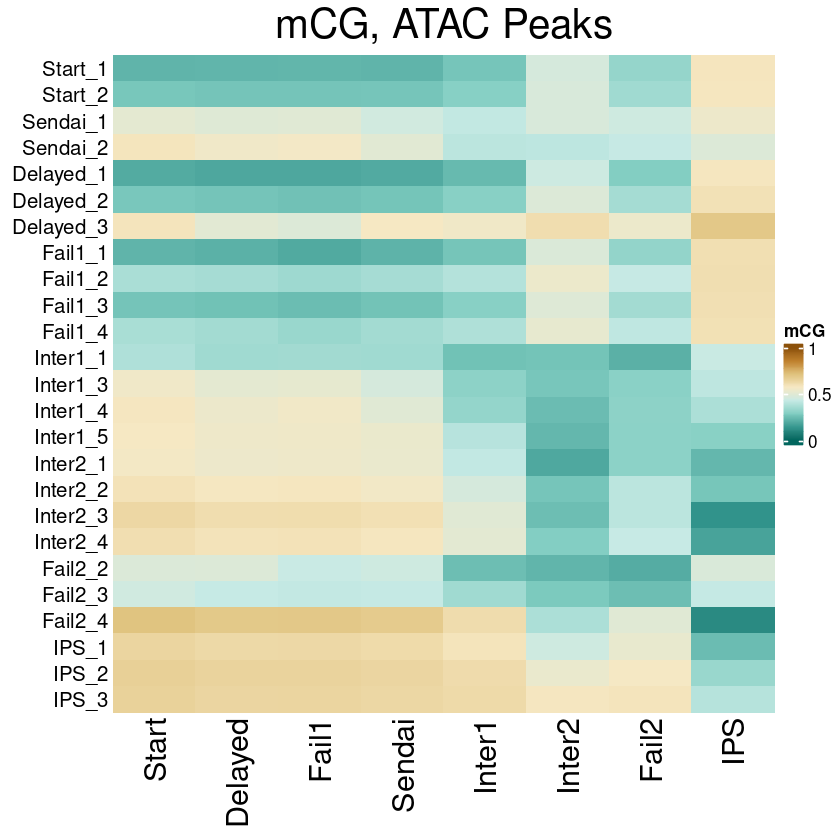

In [ ]:
clusts <- paste(rep(tmp_order, each = length(donors)), rep(donors, times = length(tmp_order)), sep = "_")
mcg_zscore = as.data.frame(fread(paste0(projdir, '/csv/figure3/rna_cluster_donor_chromhmm_peaks_mcg.csv')))
mcg_zscore <- mcg_zscore[mcg_zscore$peak_type == 'Enhancer',]
rownames(mcg_zscore) <- mcg_zscore$V1
mcg_zscore <- mcg_zscore[,-1]

to_plot <- mcg_zscore[,clusts]
rownames(to_plot) <- mcg_zscore$sub_clust
to_plot <- as.matrix(to_plot)
colnames(to_plot) <- sub("*_...", "", colnames(to_plot))
col_fun <- colorRamp2(seq(0, 1, length.out = 8), rev(brewer.pal(8, "BrBG")))

row_ids <- to_plot[[1]]
data_only <- to_plot[ , -1]

col_groups <- colnames(data_only)
unique_groups <- unique(col_groups)

averaged <- sapply(unique_groups, function(g) {
  rowMeans(data_only[, col_groups == g, drop = FALSE], na.rm = TRUE)
})

result <- as.data.frame(averaged)
result <- cbind(ID = row_ids, result)
result <- result[,-1]

fail_order <- c('Start', 'Delayed', 'Fail1', 'Sendai', 'Inter1', 'Inter2', 'Fail2', 'IPS')
result <- result[,fail_order]

w = 7
h = 7
options(repr.plot.width = w, repr.plot.height = h)

p1 <- Heatmap(
    result,
    name = "mCG",
    col = col_fun,
    row_names_side = "left",
    column_names_side = "bottom",
    show_row_names = TRUE,
    show_column_names = TRUE,
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_gp = gpar(fontsize = 12),
    column_names_gp = gpar(fontsize = 18),
    column_title_gp = gpar(fontsize = 24),
    column_names_rot = 90,
    row_title_rot = 90,
    column_title = 'mCG, ATAC Peaks',
    )

p <- as.ggplot(p1) +
        base_theme

p

### F: PMD metagene across the Fail1 branch

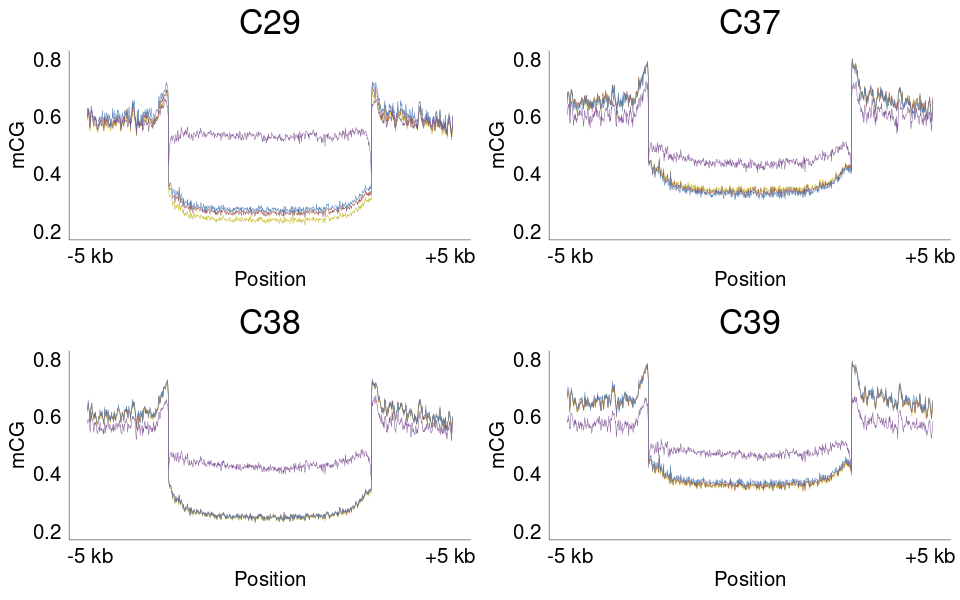

In [ ]:
pmd_flank_path = paste0(projdir, '/csv/figure3/pmds_flank_metagene.csv')
pmd_flank = read.csv(pmd_flank_path, sep='\t')
pmd_flank$donor <- factor(pmd_flank$donor, levels=donors)
pmd_flank$cluster <- factor(pmd_flank$cluster, levels=tmp_order)

slack = 6
tmp_breaks <- c(min(pmd_flank$tmp) + slack, max(pmd_flank$tmp) - slack)
tmp_hexes <- c('#C4B921', '#9C4F43', '#4F7EB8', '#7F5194')

plot_pmds <- function(pmd_flank, d) {

  tmp_flank <- pmd_flank[pmd_flank$donor == d, ]

  whitelist <- c('Start', 'Delayed', 'Fail1', 'IPS')
  final_flank <- tmp_flank[tmp_flank$cluster %in% whitelist, ]

  ggplot(final_flank, aes(x = tmp, y = X0, color = cluster, group = cluster)) +
   geom_line(linewidth=0.1) +
    labs(x = "Position", y = "mCG", title = d) +
    coord_cartesian(ylim = c(0.2, 0.8)) +
    scale_x_continuous(breaks = tmp_breaks, labels = c("-5 kb", "+5 kb")) +
    theme_bw() +
    base_theme +
    scale_color_manual(values = tmp_hexes) +
    theme(
      axis.text.x = element_text(size=12, color='black'),
        axis.text.y = element_text(size=12,angle=0, color='black'),
        axis.title.x = element_text(size=12),
        axis.title.y = element_text(size=12),
        axis.line = element_blank(),
         axis.line.x = element_line(linewidth=0.1),
         axis.line.y = element_line(linewidth=0.1),
      legend.position = 'none',
      plot.title = element_text(size = 20, hjust = 0.5)
    )
}

plot_list <- list()
for (i in seq_along(donors)) {
    d = donors[i]
    p <- plot_pmds(pmd_flank, d)
    plot_list[[i]] <- p
}

w = 8
h = 5
options(repr.plot.width=w, repr.plot.height=h)

combined_plot <- plot_grid(plotlist=plot_list, nrow=2, ncol=2)
combined_plot

### I: PMD methylation across the Fail2 branch

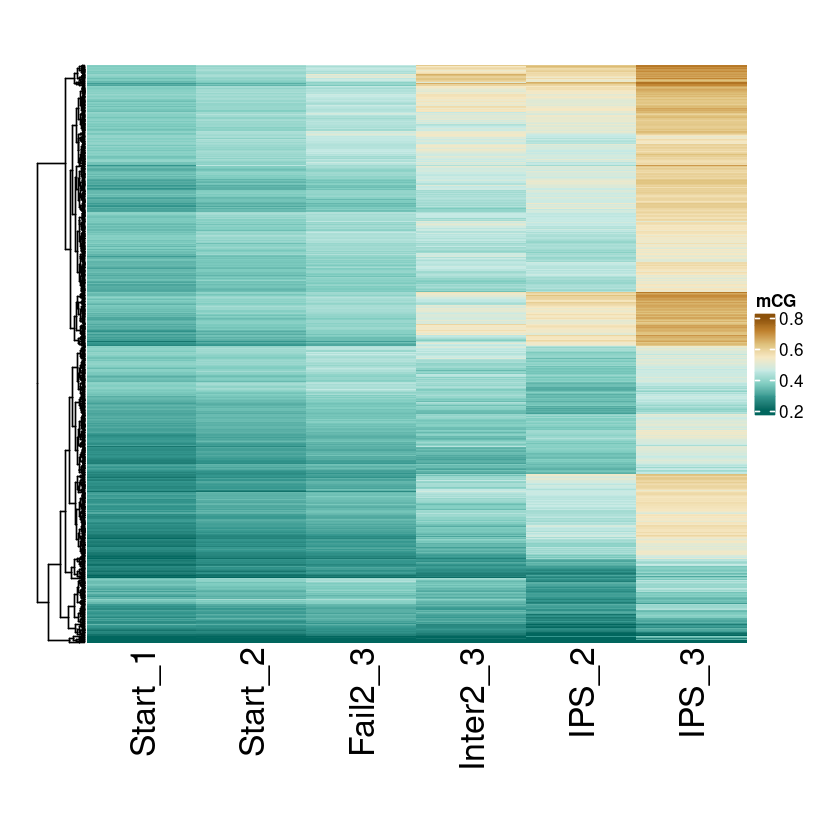

In [ ]:
pmd_mcg_path = paste0(projdir, '/csv/figure3/rev_class_pmd_mcg.csv')
pmd_mcg = as.data.frame(fread(pmd_mcg_path, sep='\t'))
pmd_mcg <- pmd_mcg[,-1]

w = 7
h = 7
options(repr.plot.width=w, repr.plot.height=h)

col_fun <- colorRamp2(seq(0.2, 0.8, length.out = 8), rev(brewer.pal(8, "BrBG")))

ht <- Heatmap(pmd_mcg,
        name = "mCG",
        col = col_fun,
        cluster_rows = TRUE,
        cluster_columns = FALSE,
        show_row_names = TRUE,
        show_column_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 20),
        column_names_gp = gpar(fontsize = 20, rot = 90),
        heatmap_width = unit(15, "cm"),
        heatmap_height = unit(15, "cm"))

ht

### J: PMD metagene across the Fail2 branch

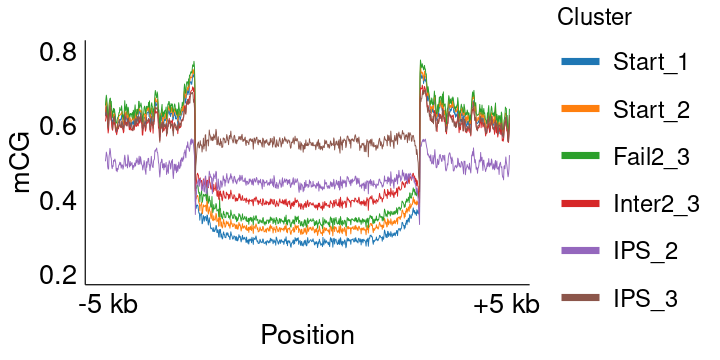

In [ ]:
tmp_hexes <- c('#1F77B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD', '#8C564B', '#D9D9D9')
names(tmp_hexes) <- c('Start_1', 'Start_2', 'Fail2_3', 'Inter2_3', 'IPS_2', 'IPS_3')

pmd_mcg_path = paste0(projdir, '/csv/figure3/pgp_rev_class_pmds_metagene.csv')
pmd_mcg = as.data.frame(fread(pmd_mcg_path, sep='\t'))
pmd_mcg <- pmd_mcg[,-1]

colnames(pmd_mcg) <- c('mCG', 'tmp', 'sample')
whitelist <- c('Start_1', 'Start_2', 'Fail2_3', 'Inter2_3', 'IPS_2', 'IPS_3')
mask <- pmd_mcg$sample %in% whitelist
tmp_mcg <- pmd_mcg[mask,]
tmp_mcg$sample <- factor(tmp_mcg$sample, levels=whitelist)

slack = 6
tmp_breaks <- c(min(pmd_mcg$tmp) + slack, max(pmd_mcg$tmp) - slack)

w = 6
h = 3
options(repr.plot.width=w, repr.plot.height=h)

ggplot(tmp_mcg, aes(x = tmp, y = mCG, color = sample, group = sample)) +
  geom_line(size = 0.2) +
labs(x = "Position", y = "mCG", title='', color='Cluster') +
 coord_cartesian(ylim = c(0.2, 0.8)) +
    scale_x_continuous(breaks = tmp_breaks, labels = c("-5 kb", "+5 kb")) +
  theme_bw() +
   base_theme +
   theme(axis.text.x = element_text(size=16, color='black'),
        axis.text.y = element_text(size=16,angle=0, color='black'),
        axis.title.x = element_text(size=16),
        axis.title.y = element_text(size=16),
        axis.line.x = element_line(size=0.25),
      axis.line.y = element_line(size=0.25),
         legend.position = 'right',
         legend.key.size = unit(1, "cm"),
         legend.text = element_text(size = 14),
         legend.title = element_text(size=14)) +
        scale_color_manual(values = tmp_hexes) +
          guides(color = guide_legend(override.aes = list(linewidth = 1.5)),
            shape = guide_legend(title = ''))

### L: mCG at early-IPS peaks in the Fail2 branch

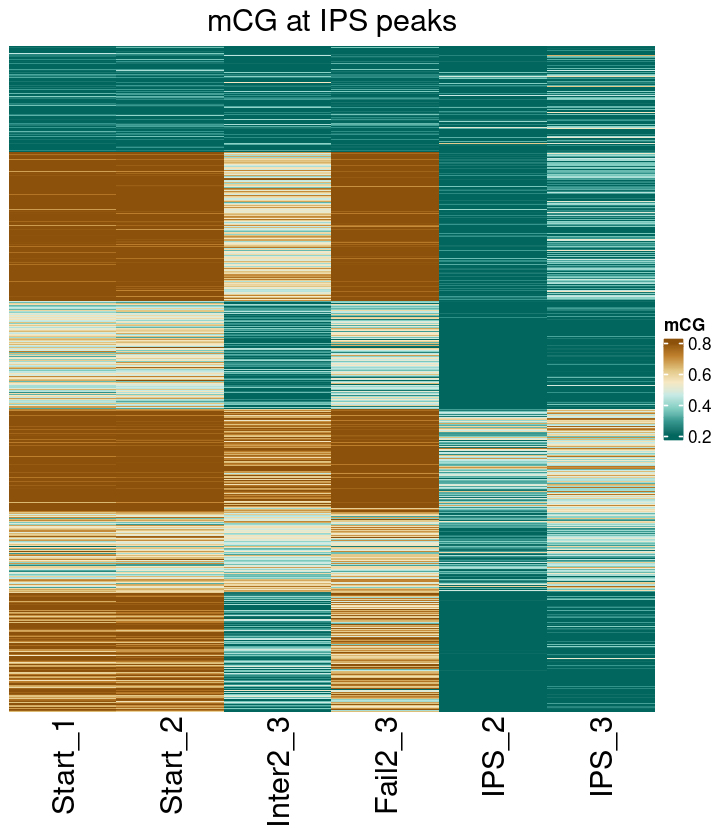

In [ ]:
enh_mcg_path = paste0(projdir, '/csv/figure3/rev_class_chromhmm_peaks_mcg.csv')
enh_mcg = as.data.frame(fread(enh_mcg_path, sep='\t'))
enh_mcg <- enh_mcg[,-1]

col_fun <- colorRamp2(seq(0.2, 0.8, length.out = 8), rev(brewer.pal(8, "BrBG")))

w = 6
h = 7
options(repr.plot.width = w, repr.plot.height = h)

ht <- Heatmap(
    enh_mcg,
    name = "mCG",
    col = col_fun,
    row_names_side = "left",
    column_names_side = "bottom",
    show_row_names = FALSE,
    show_column_names = TRUE,
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_gp = gpar(fontsize = 12),
    column_names_gp = gpar(fontsize = 18),
    column_title_gp = gpar(fontsize = 18),
    column_names_rot = 90,
    row_title_rot = 90,
    column_title = 'mCG at IPS peaks',
    )

ht

In [ ]:
sessionInfo()

In [ ]:
Sys.time()